In [1]:
# Loads packages and prepares Depressionlabels.csv 
import pandas as pd
import glob
import os
import re
import fileinput
import numpy as np

files = glob.glob("acoustics/*_utterance_agg.csv")
numbers = [int(re.search(r'acoustics\\(\d{3})_utterance_agg.csv', f).group(1)) for f in files]

headers = ['Confidence,Loudness_sma3,alphaRatio_sma3,hammarbergIndex_sma3,slope0-500_sma3,slope500-1500_sma3,spectralFlux_sma3,mfcc1_sma3,mfcc2_sma3,mfcc3_sma3,mfcc4_sma3,F0semitoneFrom27.5Hz_sma3nz,jitterLocal_sma3nz,shimmerLocaldB_sma3nz,HNRdBACF_sma3nz,logRelF0-H1-H2_sma3nz,logRelF0-H1-A3_sma3nz,F1frequency_sma3nz,F1bandwidth_sma3nz,F1amplitudeLogRelF0_sma3nz,F2frequency_sma3nz,F2amplitudeLogRelF0_sma3nz,F3frequency_sma3nz,F3amplitudeLogRelF0_sma3nz']
headers = [h.strip() for h in headers[0].split(",")]

df = pd.read_csv("DepressionLabels.csv")
filtered = df[df['ID'].isin(numbers)]

for h in headers:
    filtered[h] = None   # or np.nan
filtered.to_csv("DepressionLabels_filtered.csv", index=False)

C:\Users\kylef\miniconda3\envs\ml2\lib\site-packages\ipykernel_launcher.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


In [2]:
# Prepares a single csv file which as all data, where entries are the averages taken from the utterance files
out = pd.read_csv('DepressionLabels_filtered.csv')

# Loops through the utterance files, setting variables equal to the mean of each column in the i utterance file
for num in numbers:
    f = f"acoustics/{num}_utterance_agg.csv"
    df = pd.read_csv(f)
    df = df.drop(df.columns[0:5], axis=1)
    
    # Sets variables equals to the mean of each column in i_utterance_agg.csv
    Confidence = df['Confidence'].mean()
    Loudness_sma3 = df['Loudness_sma3'].mean()
    alphaRatio_sma3 = df['alphaRatio_sma3'].mean()
    hammarbergIndex_sma3 = df['hammarbergIndex_sma3'].mean()
    slope0_500_sma3 = df['slope0-500_sma3'].mean()
    slope500_1500_sma3 = df['slope500-1500_sma3'].mean()
    spectralFlux_sma3 = df['spectralFlux_sma3'].mean()
    mfcc1_sma3 = df['mfcc1_sma3'].mean()
    mfcc2_sma3 = df['mfcc2_sma3'].mean()
    mfcc3_sma3 = df['mfcc3_sma3'].mean()
    mfcc4_sma3 = df['mfcc4_sma3'].mean()
    F0semitoneFrom27_5Hz_sma3nz = df['F0semitoneFrom27.5Hz_sma3nz'].mean()
    jitterLocal_sma3nz = df['jitterLocal_sma3nz'].mean()
    shimmerLocaldB_sma3nz = df['shimmerLocaldB_sma3nz'].mean()
    HNRdBACF_sma3nz = df['HNRdBACF_sma3nz'].mean()
    logRelF0_H1_H2_sma3nz = df['logRelF0-H1-H2_sma3nz'].mean()
    logRelF0_H1_A3_sma3nz = df['logRelF0-H1-A3_sma3nz'].mean()
    F1frequency_sma3nz = df['F1frequency_sma3nz'].mean()
    F1bandwidth_sma3nz = df['F1bandwidth_sma3nz'].mean()
    F1amplitudeLogRelF0_sma3nz = df['F1amplitudeLogRelF0_sma3nz'].mean()
    F2frequency_sma3nz = df['F2frequency_sma3nz'].mean()
    F2amplitudeLogRelF0_sma3nz = df['F2amplitudeLogRelF0_sma3nz'].mean()
    F3frequency_sma3nz = df['F3frequency_sma3nz'].mean()
    F3amplitudeLogRelF0_sma3nz = df['F3amplitudeLogRelF0_sma3nz'].mean()
    
    #Populates a dataframe with the variables generated above
    out.loc[out["ID"] == num, 'Confidence'] = Confidence
    out.loc[out["ID"] == num, 'Loudness_sma3'] = Loudness_sma3
    out.loc[out["ID"] == num, 'alphaRatio_sma3'] = alphaRatio_sma3
    out.loc[out["ID"] == num, 'hammarbergIndex_sma3'] = hammarbergIndex_sma3
    out.loc[out["ID"] == num, 'slope0-500_sma3'] = slope0_500_sma3
    out.loc[out["ID"] == num, 'slope500-1500_sma3'] = slope500_1500_sma3
    out.loc[out["ID"] == num, 'spectralFlux_sma3'] = spectralFlux_sma3
    out.loc[out["ID"] == num, 'mfcc1_sma3'] = mfcc1_sma3
    out.loc[out["ID"] == num, 'mfcc2_sma3'] = mfcc2_sma3
    out.loc[out["ID"] == num, 'mfcc3_sma3'] = mfcc3_sma3
    out.loc[out["ID"] == num, 'mfcc4_sma3'] = mfcc4_sma3
    out.loc[out["ID"] == num, 'F0semitoneFrom27.5Hz_sma3nz'] = F0semitoneFrom27_5Hz_sma3nz
    out.loc[out["ID"] == num, 'jitterLocal_sma3nz'] = jitterLocal_sma3nz
    out.loc[out["ID"] == num, 'shimmerLocaldB_sma3nz'] = shimmerLocaldB_sma3nz
    out.loc[out["ID"] == num, 'HNRdBACF_sma3nz'] = HNRdBACF_sma3nz
    out.loc[out["ID"] == num, 'logRelF0-H1-H2_sma3nz'] = logRelF0_H1_H2_sma3nz
    out.loc[out["ID"] == num, 'logRelF0-H1-A3_sma3nz'] = logRelF0_H1_A3_sma3nz
    out.loc[out["ID"] == num, 'F1frequency_sma3nz'] = F1frequency_sma3nz
    out.loc[out["ID"] == num, 'F1bandwidth_sma3nz'] = F1bandwidth_sma3nz
    out.loc[out["ID"] == num, 'F1amplitudeLogRelF0_sma3nz'] = F1amplitudeLogRelF0_sma3nz
    out.loc[out["ID"] == num, 'F2frequency_sma3nz'] = F2frequency_sma3nz
    out.loc[out["ID"] == num, 'F2amplitudeLogRelF0_sma3nz'] = F2amplitudeLogRelF0_sma3nz
    out.loc[out["ID"] == num, 'F3frequency_sma3nz'] = F3frequency_sma3nz
    out.loc[out["ID"] == num, 'F3amplitudeLogRelF0_sma3nz'] = F3amplitudeLogRelF0_sma3nz
    
# Saves populated dataframe
out.to_csv("praying.csv", index=False)

In [3]:
# Prepares different input datasets with different groupings of PHQ_Score. The df.loc lines can be removed to revert this to the
# 2, 3, or 4. It is currently configured for a 5-class classification based on the PHQ-9 guidelines.

df = pd.read_csv('praying.csv')
df.insert(2, "Class", np.nan)

df.loc[df["PHQ_Score"].between(0, 4), "Class"] = '0'
df.loc[df["PHQ_Score"].between(5, 9), "Class"] = '1'
df.loc[df["PHQ_Score"].between(10, 14), "Class"] = '2'
df.loc[df["PHQ_Score"].between(15, 19), "Class"] = '3'
df.loc[df["PHQ_Score"].between(20, 27), "Class"] = '4'

df = df.drop(columns=['ID', 'PHQ_Score'])
df.head()
df.to_csv("5_class.csv", index=False)

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import r2_score
from sklearn.datasets import make_regression
from sklearn.tree import export_graphviz
import graphviz
from sklearn import tree
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error

0.07796811755854502
0.35185185185185186


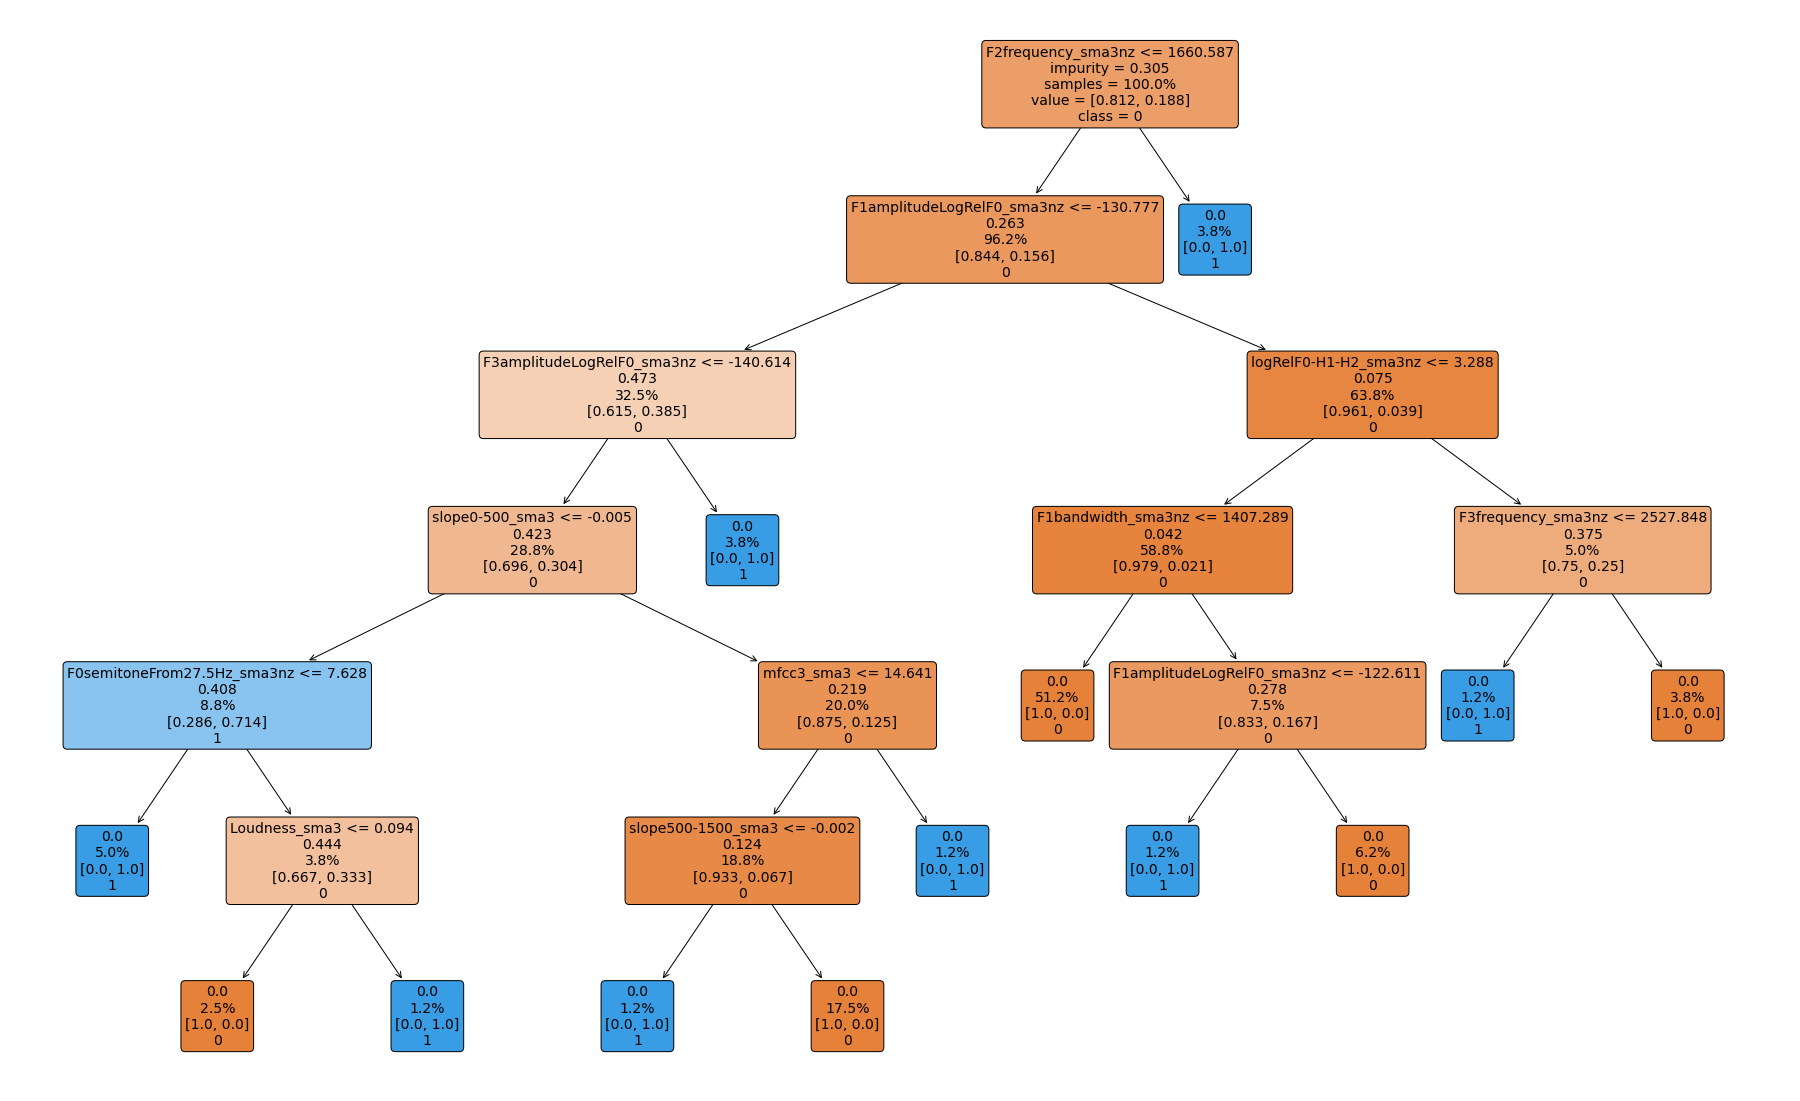

In [5]:
df = pd.read_csv('2_class.csv')
X = df.iloc[:, 1:25]
y = df.iloc[:, 0]

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1, test_size = 0.4)
dtc = DecisionTreeClassifier()
dtc.fit(X_train, y_train)
y_pred = dtc.predict(X_test)
#print(confusion_matrix(y_test, y_pred))
#print(classification_report(y_test, y_pred))
print(np.corrcoef(y_pred, y_test)[0, 1])
print(mean_absolute_error(y_test, y_pred))

# Classes = unique values in the Class column
class_names = df["Class"].unique().astype(str)

# Feature names = all columns from column 2 to the end
feature_names = df.columns[1:].tolist()

# Make very large clean figure
plt.figure(figsize=(32, 20))

# Temporarily hide impurity (removes "samples" & "value")
old_criterion = dtc.criterion
dtc.criterion = None

tree.plot_tree(
    dtc,
    feature_names=feature_names,
    class_names=class_names,
    filled=True,
    rounded=True,
    proportion=True,  # shrinks text by using percentages
    label="root",     # hides samples and value lines
    fontsize=14       # increase text size
)

# Restore original model criterion afterward
dtc.criterion = old_criterion

plt.show()

0.009025414117358679
0.5740740740740741


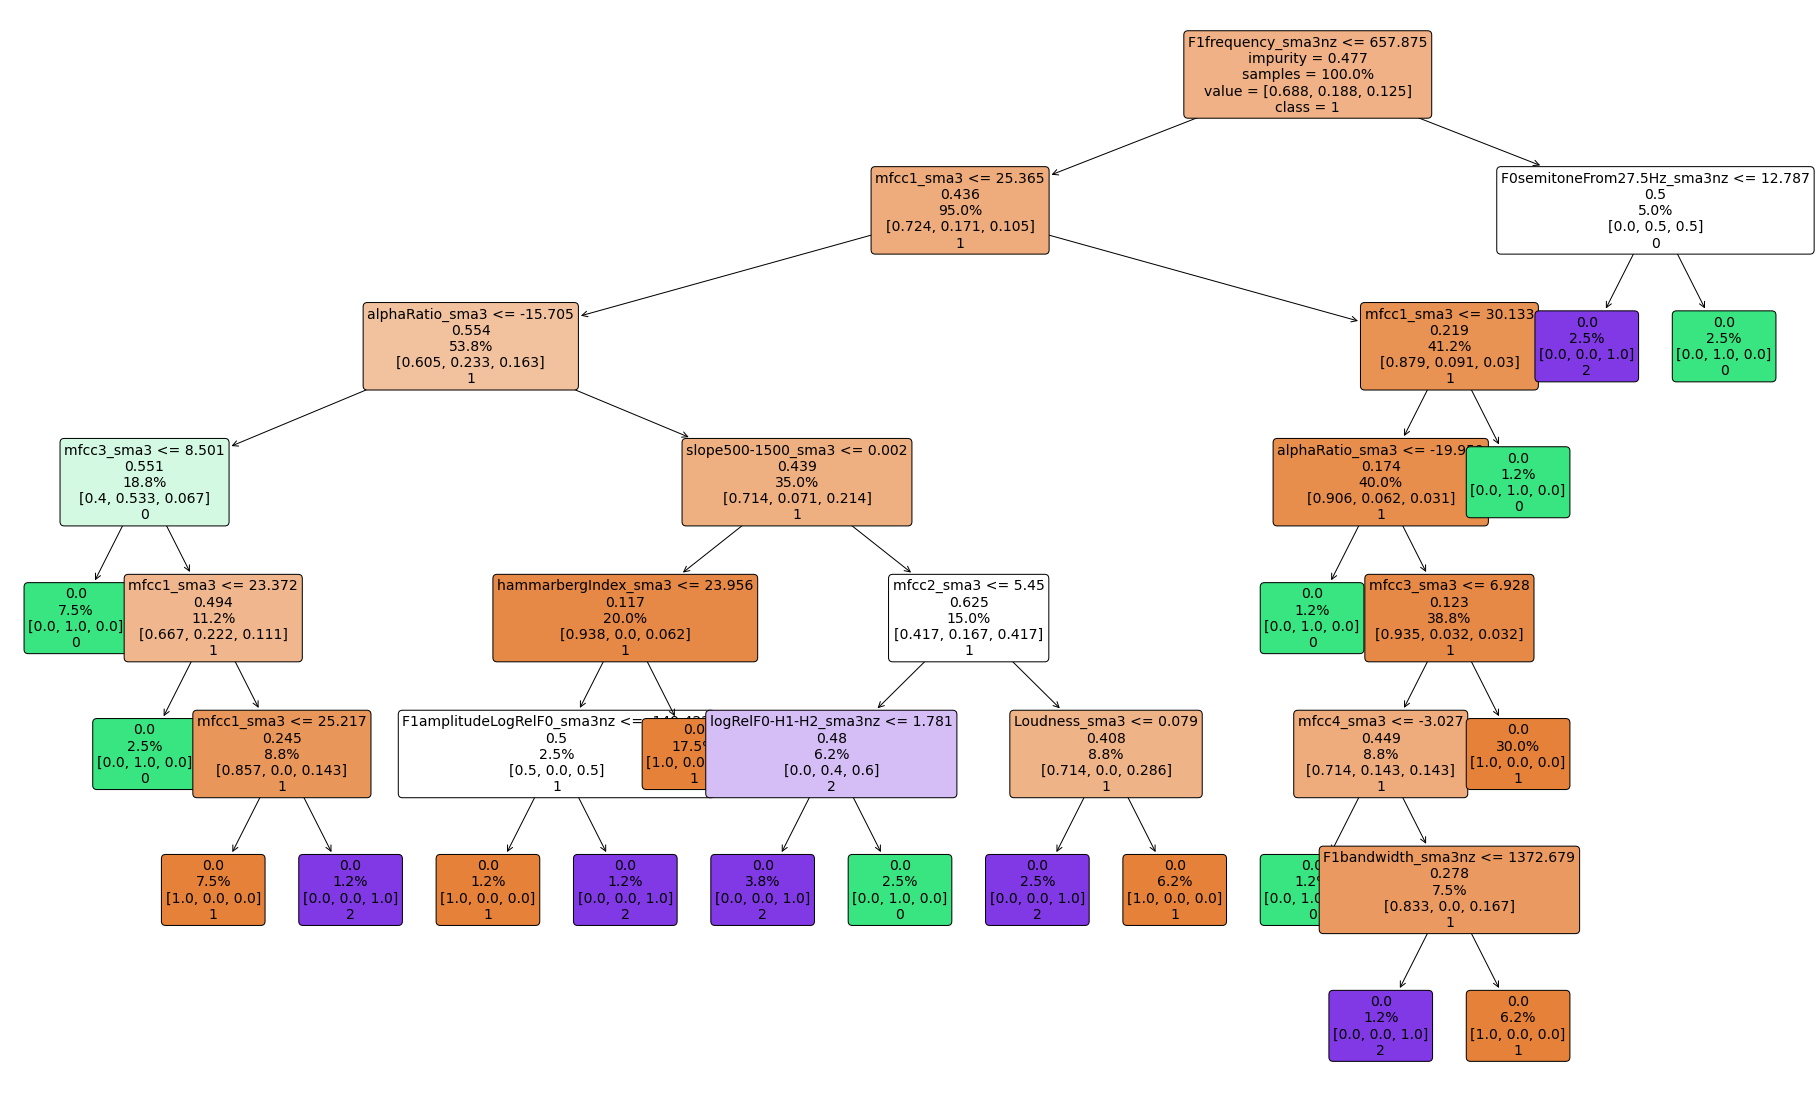

In [6]:
df = pd.read_csv('3_class.csv')
X = df.iloc[:, 1:25]
y = df.iloc[:, 0]

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1, test_size = 0.4)
dtc = DecisionTreeClassifier()
dtc.fit(X_train, y_train)
y_pred = dtc.predict(X_test)
#print(confusion_matrix(y_test, y_pred))
#print(classification_report(y_test, y_pred))
print(np.corrcoef(y_pred, y_test)[0, 1])
print(mean_absolute_error(y_test, y_pred))

# Classes = unique values in the Class column
class_names = df["Class"].unique().astype(str)

# Feature names = all columns from column 2 to the end
feature_names = df.columns[1:].tolist()

# Make very large clean figure
plt.figure(figsize=(32, 20))

# Temporarily hide impurity (removes "samples" & "value")
old_criterion = dtc.criterion
dtc.criterion = None

tree.plot_tree(
    dtc,
    feature_names=feature_names,
    class_names=class_names,
    filled=True,
    rounded=True,
    proportion=True,  # shrinks text by using percentages
    label="root",     # hides samples and value lines
    fontsize=14       # increase text size
)

# Restore original model criterion afterward
dtc.criterion = old_criterion

plt.show()

0.1580889812233983
0.7407407407407407


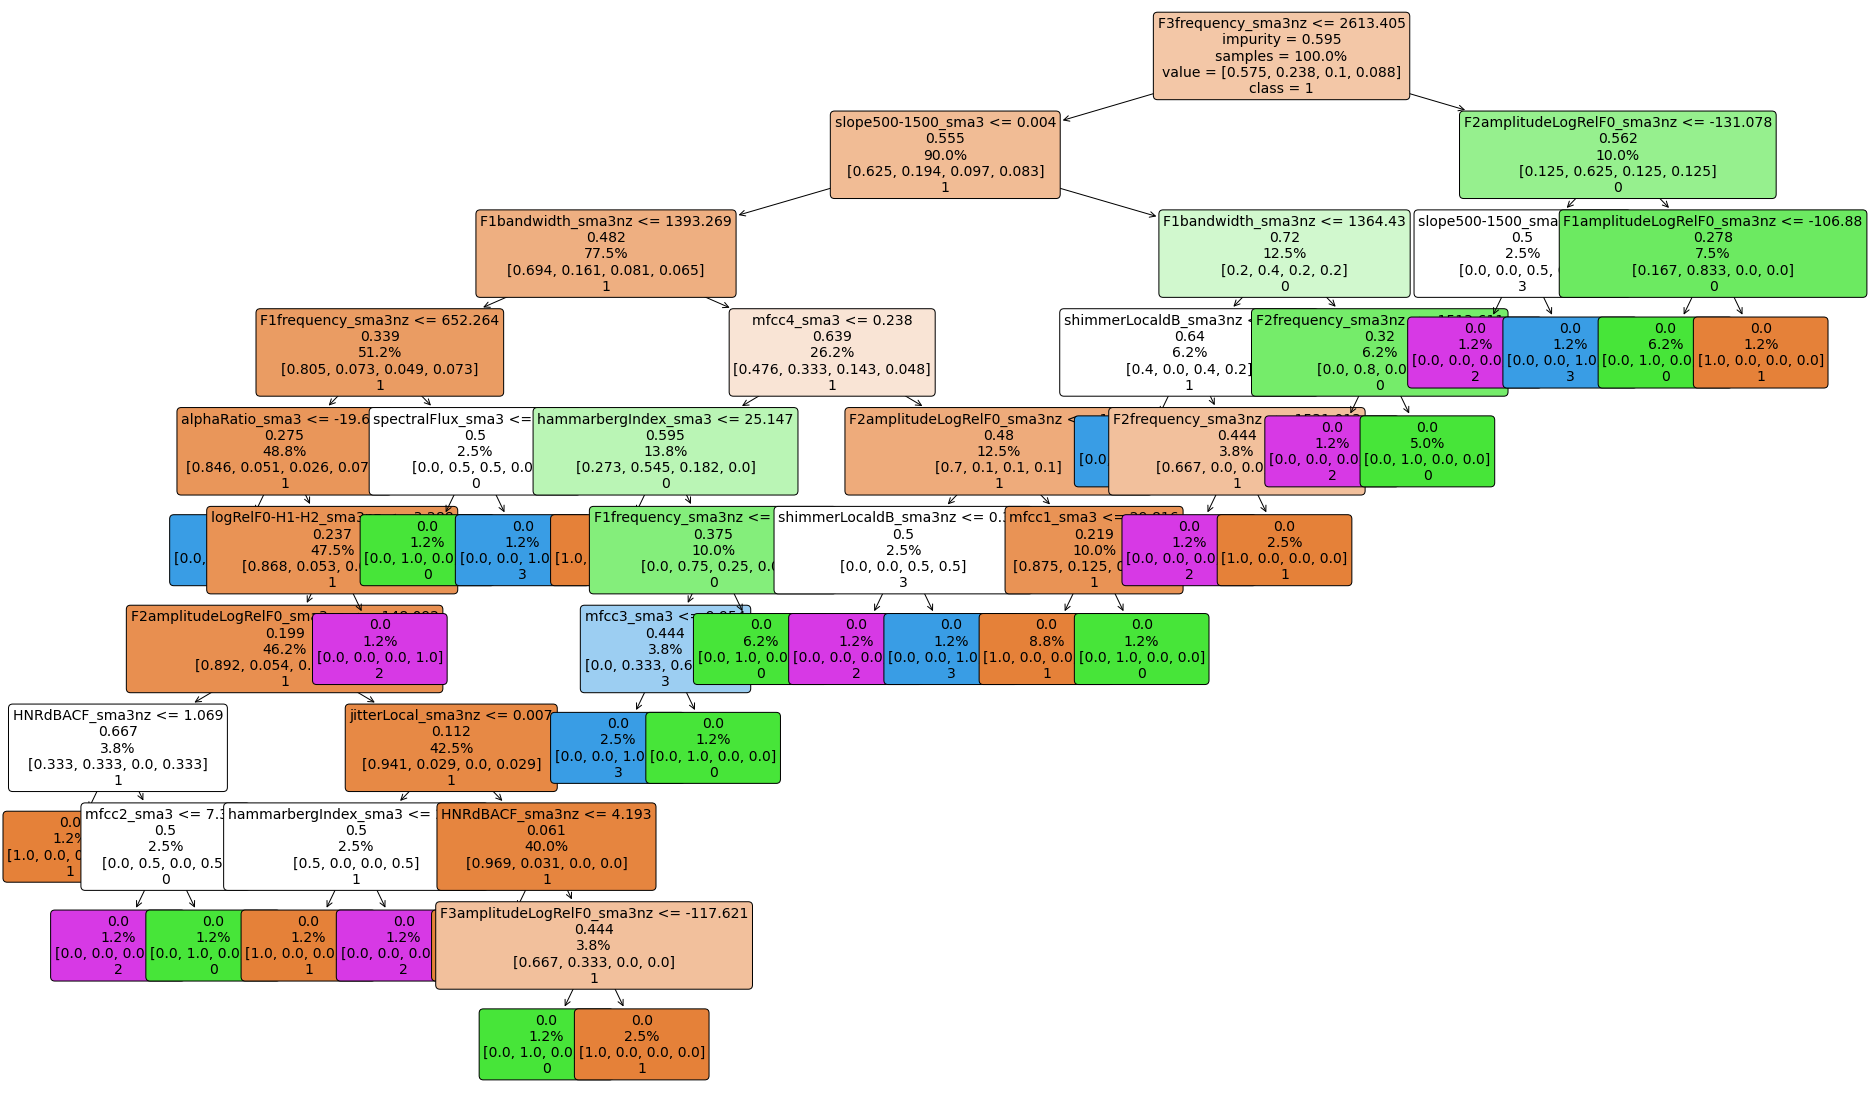

In [11]:
df = pd.read_csv('4_class.csv')
X = df.iloc[:, 1:25]
y = df.iloc[:, 0]

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1, test_size = 0.4)
dtc = DecisionTreeClassifier()
dtc.fit(X_train, y_train)
y_pred = dtc.predict(X_test)
#print(confusion_matrix(y_test, y_pred))
#print(classification_report(y_test, y_pred))
print(np.corrcoef(y_pred, y_test)[0, 1])
print(mean_absolute_error(y_test, y_pred))

# Classes = unique values in the Class column
class_names = df["Class"].unique().astype(str)

# Feature names = all columns from column 2 to the end
feature_names = df.columns[1:].tolist()

# Make very large clean figure
plt.figure(figsize=(32, 20))

# Temporarily hide impurity (removes "samples" & "value")
old_criterion = dtc.criterion
dtc.criterion = None

tree.plot_tree(
    dtc,
    feature_names=feature_names,
    class_names=class_names,
    filled=True,
    rounded=True,
    proportion=True,  # shrinks text by using percentages
    label="root",     # hides samples and value lines
    fontsize=14       # increase text size
)

# Restore original model criterion afterward
dtc.criterion = old_criterion

plt.show()

-0.01998042210418887
1.1481481481481481


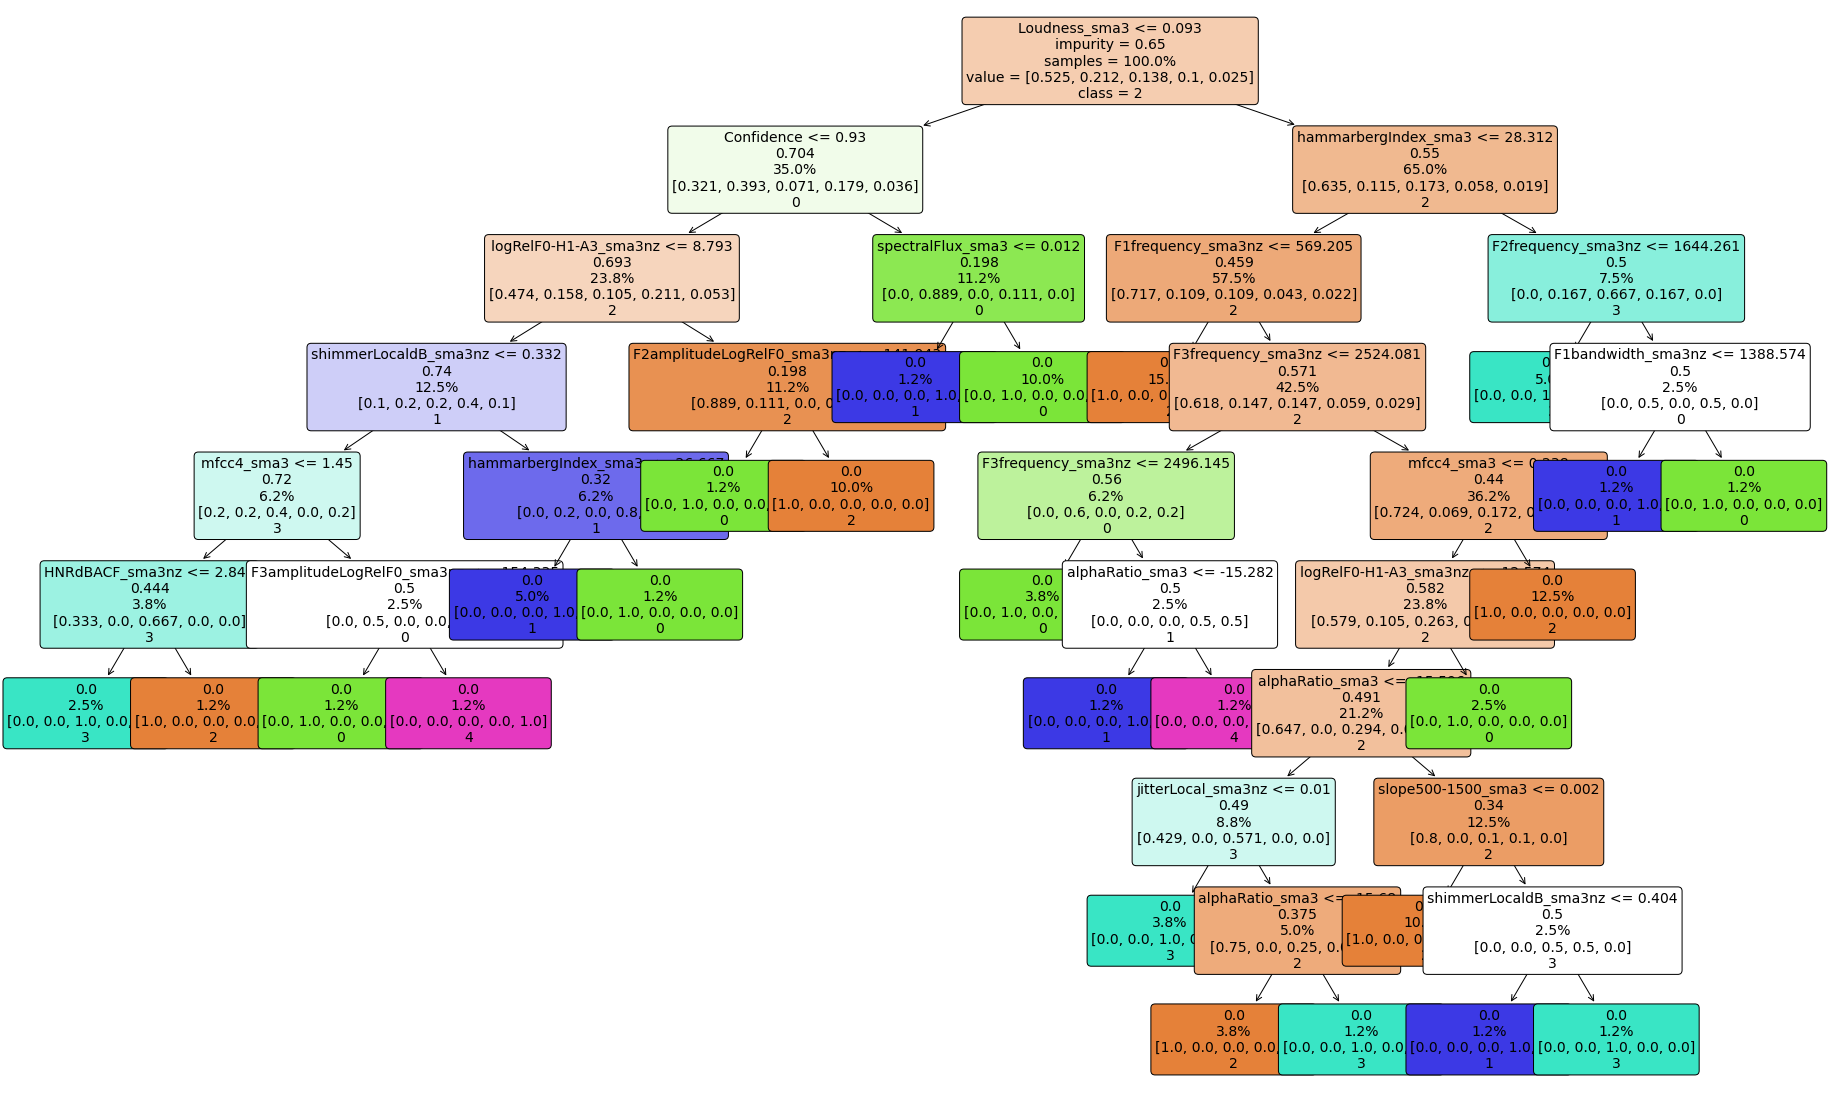

In [8]:
df = pd.read_csv('5_class.csv')
X = df.iloc[:, 1:25]
y = df.iloc[:, 0]

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1, test_size = 0.4)
dtc = DecisionTreeClassifier()
dtc.fit(X_train, y_train)
y_pred = dtc.predict(X_test)
#print(confusion_matrix(y_test, y_pred))
#print(classification_report(y_test, y_pred))
print(np.corrcoef(y_pred, y_test)[0, 1])
print(mean_absolute_error(y_test, y_pred))

# Classes = unique values in the Class column
class_names = df["Class"].unique().astype(str)

# Feature names = all columns from column 2 to the end
feature_names = df.columns[1:].tolist()

# Make very large clean figure
plt.figure(figsize=(32, 20))

# Temporarily hide impurity (removes "samples" & "value")
old_criterion = dtc.criterion
dtc.criterion = None

tree.plot_tree(
    dtc,
    feature_names=feature_names,
    class_names=class_names,
    filled=True,
    rounded=True,
    proportion=True,  # shrinks text by using percentages
    label="root",     # hides samples and value lines
    fontsize=14       # increase text size
)

# Restore original model criterion afterward
dtc.criterion = old_criterion

plt.show()

# Everything below this cell is just experimentation-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

-0.07367294616134235


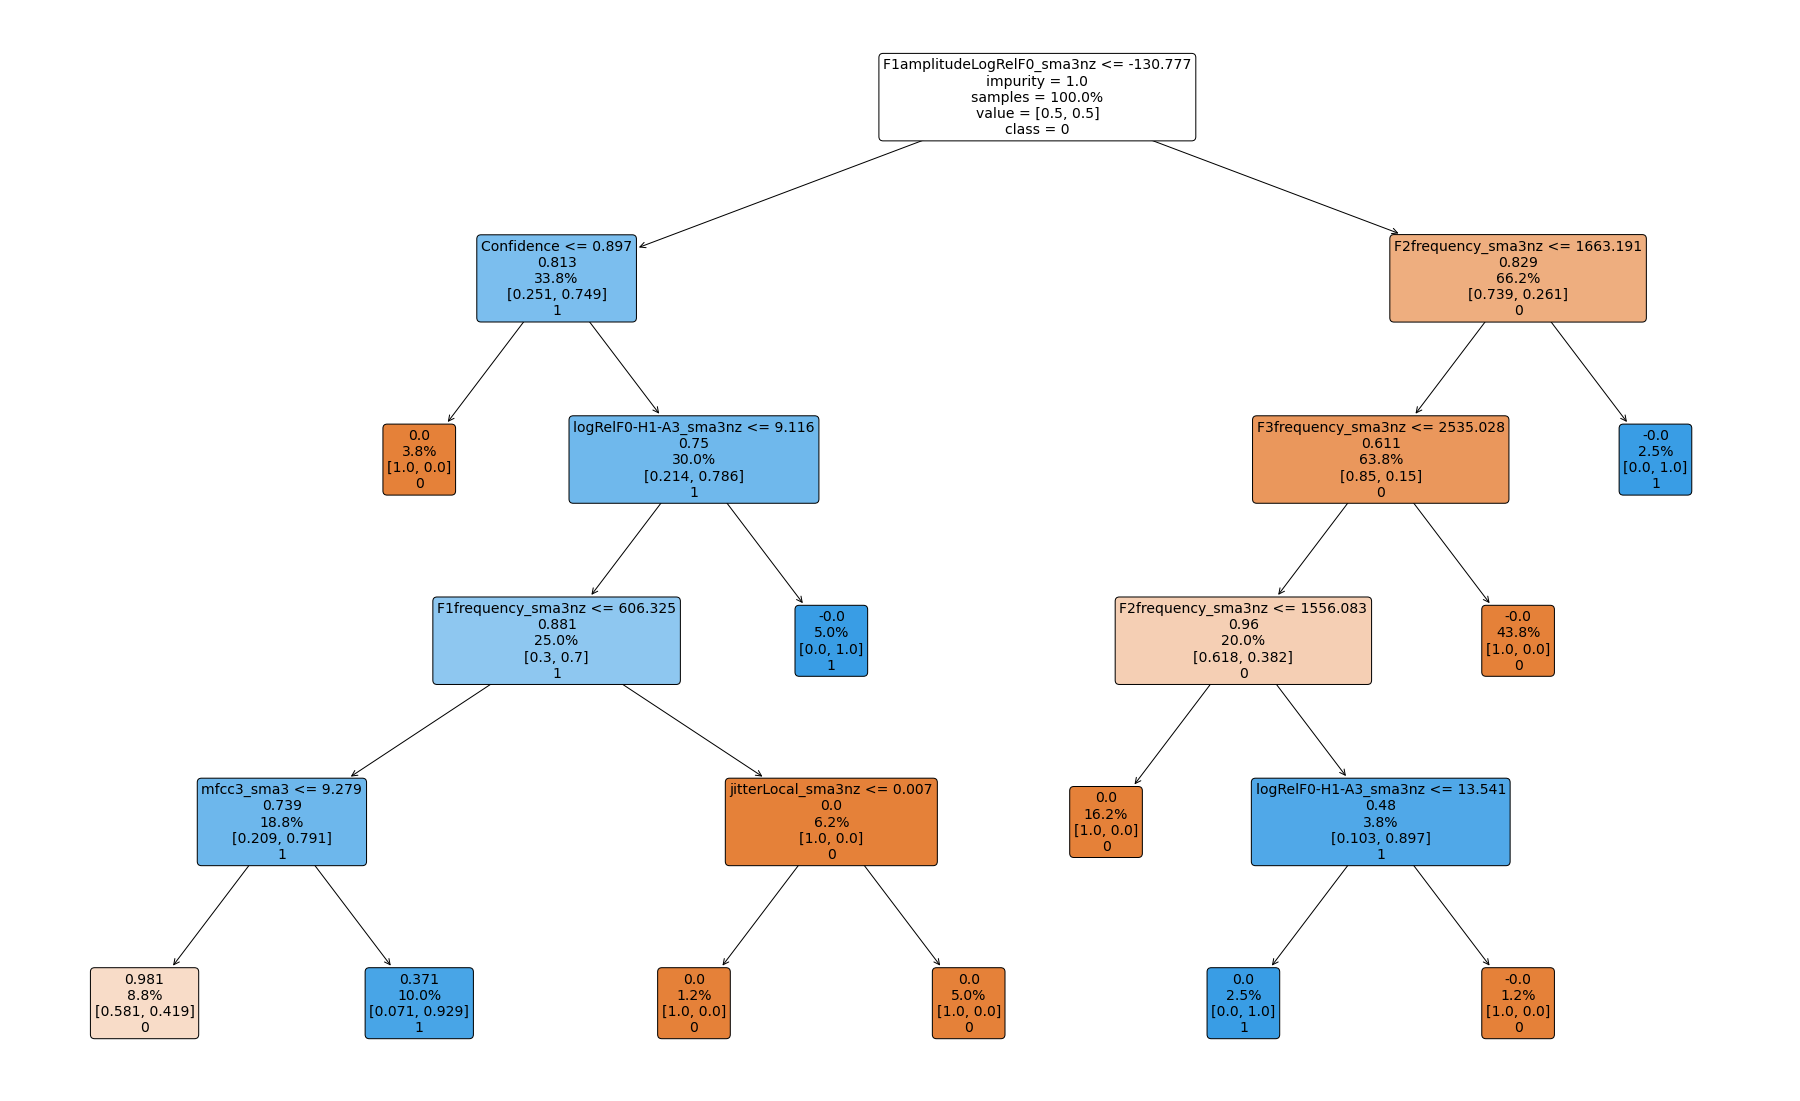

In [65]:
df = pd.read_csv('2_class.csv')
X = df.iloc[:, 1:25]
y = df.iloc[:, 0]

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1, test_size = 0.4)
dtc = DecisionTreeClassifier(criterion = 'entropy', max_depth = 5, class_weight = 'balanced')
dtc.fit(X_train, y_train)
y_pred = dtc.predict(X_test)
#print(confusion_matrix(y_test, y_pred))
#print(classification_report(y_test, y_pred))
print(np.corrcoef(y_pred, y_test)[0, 1])

# Classes = unique values in the Class column
class_names = df["Class"].unique().astype(str)

# Feature names = all columns from column 2 to the end
feature_names = df.columns[1:].tolist()

# Make very large clean figure
plt.figure(figsize=(32, 20))

# Temporarily hide impurity (removes "samples" & "value")
old_criterion = dtc.criterion
dtc.criterion = None

tree.plot_tree(
    dtc,
    feature_names=feature_names,
    class_names=class_names,
    filled=True,
    rounded=True,
    proportion=True,  # shrinks text by using percentages
    label="root",     # hides samples and value lines
    fontsize=14       # increase text size
)

# Restore original model criterion afterward
dtc.criterion = old_criterion

plt.show()

0.15848063401299375
0.6851851851851852
Average Absolute Relative Error: 0.2283950617283951


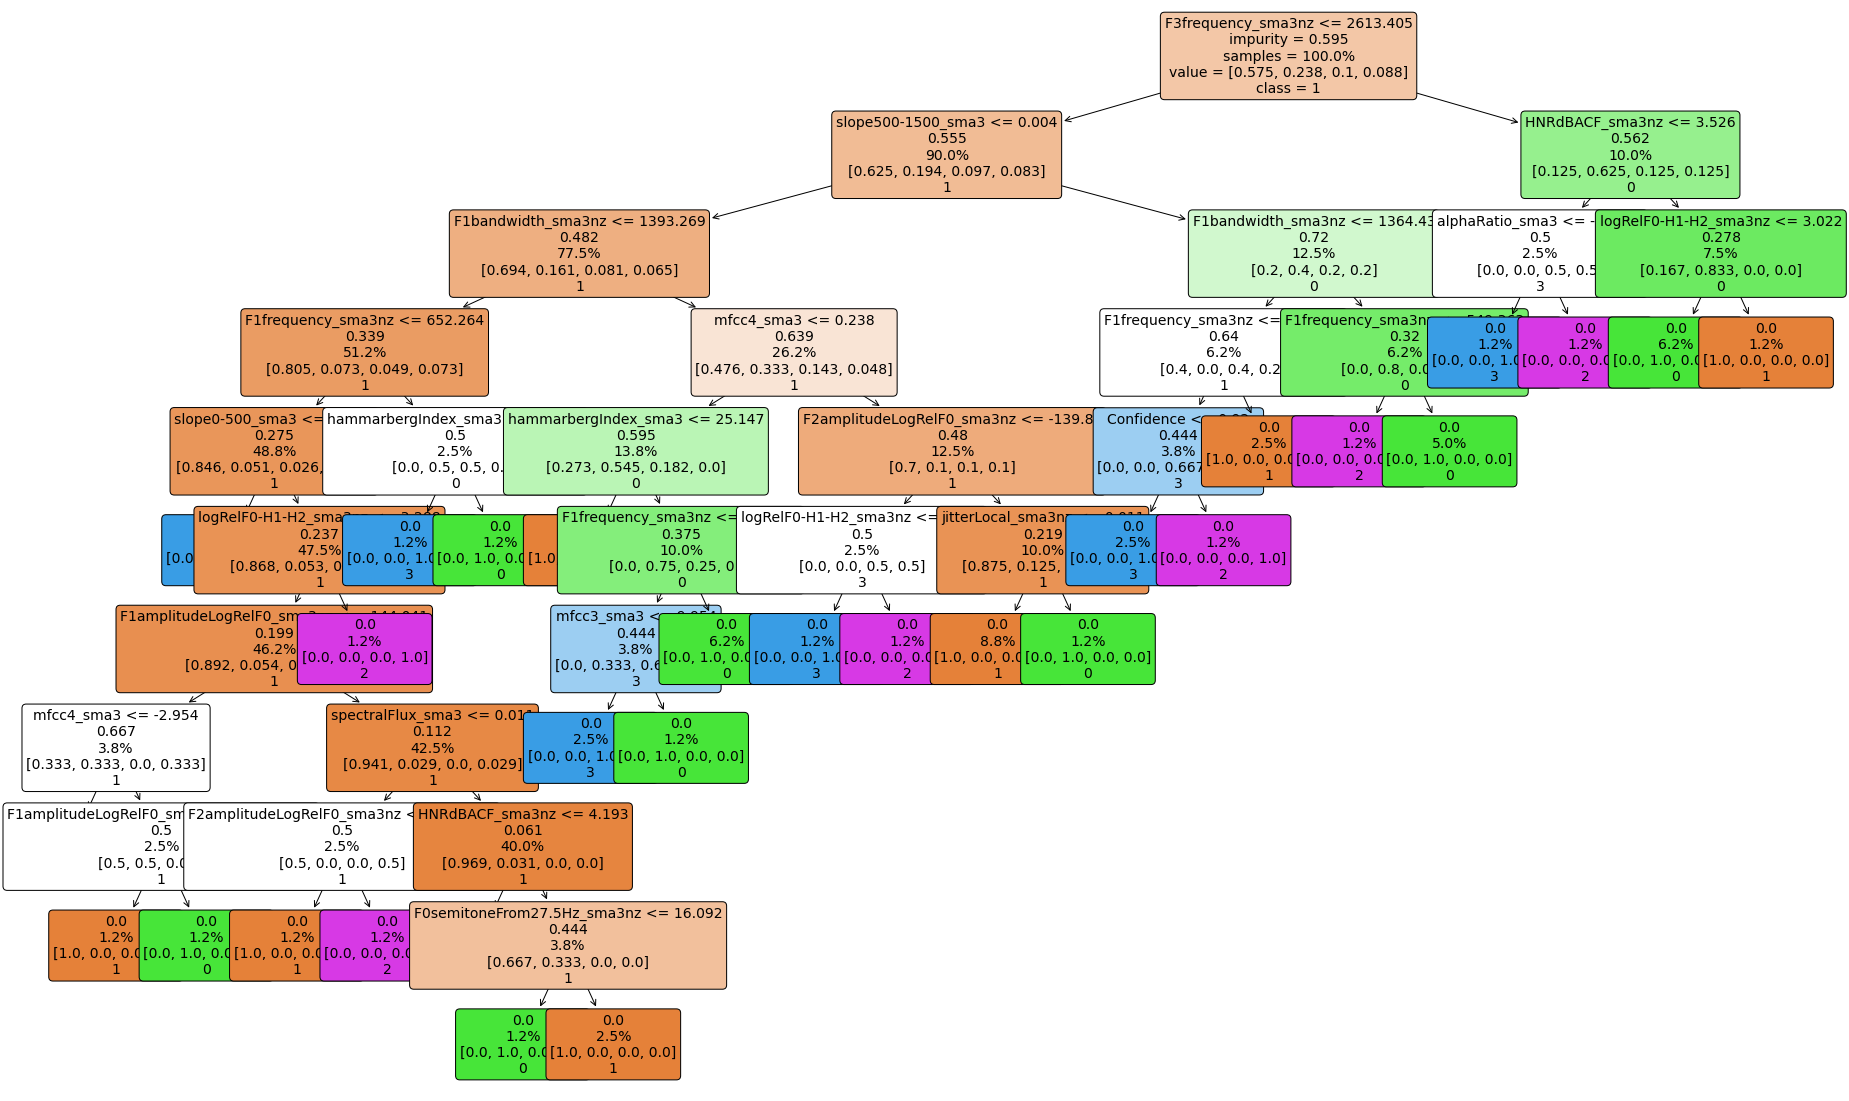

In [59]:
df = pd.read_csv('4_class.csv')
X = df.iloc[:, 1:25]
y = df.iloc[:, 0]

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1, test_size = 0.4)
dtc = DecisionTreeClassifier()
dtc.fit(X_train, y_train)
y_pred = dtc.predict(X_test)
#print(confusion_matrix(y_test, y_pred))
#print(classification_report(y_test, y_pred))
print(np.corrcoef(y_pred, y_test)[0, 1])
print(mean_absolute_error(y_test, y_pred))

#------------------------------------------------------------------------------------------------

# Maximum value for normalization
y_max = max(max(y_pred), max(y_test))  # or set it explicitly if you want

# Calculate absolute relative errors
are_list = [abs(p - t) / y_max for p, t in zip(y_pred, y_test)]

# Compute average
average_are = sum(are_list) / len(are_list)

print("Average Absolute Relative Error:", average_are)
#------------------------------------------------------------------------------------------------

# Classes = unique values in the Class column
class_names = df["Class"].unique().astype(str)

# Feature names = all columns from column 2 to the end
feature_names = df.columns[1:].tolist()

# Make very large clean figure
plt.figure(figsize=(32, 20))

# Temporarily hide impurity (removes "samples" & "value")
old_criterion = dtc.criterion
dtc.criterion = None

tree.plot_tree(
    dtc,
    feature_names=feature_names,
    class_names=class_names,
    filled=True,
    rounded=True,
    proportion=True,  # shrinks text by using percentages
    label="root",     # hides samples and value lines
    fontsize=14       # increase text size
)

# Restore original model criterion afterward
dtc.criterion = old_criterion

plt.show()

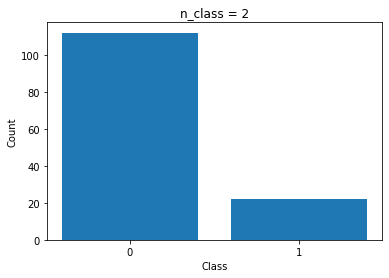

In [36]:
df = pd.read_csv('2_class.csv')
# Count the occurrences of each class
class_counts = df["Class"].value_counts().sort_index()  # sort_index keeps x-axis in order

# Create bar plot
plt.bar(class_counts.index, class_counts.values)

plt.xlabel("Class")
plt.ylabel("Count")
plt.title("n_class = 2")
plt.xticks(class_counts.index)  # ensure x-axis shows integers

plt.show()


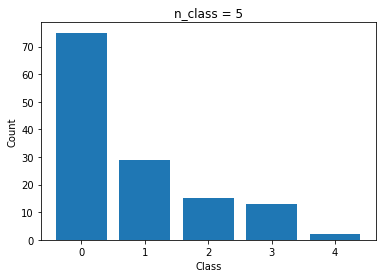

In [38]:
df = pd.read_csv('5_class.csv')
# Count the occurrences of each class
class_counts = df["Class"].value_counts().sort_index()  # sort_index keeps x-axis in order

# Create bar plot
plt.bar(class_counts.index, class_counts.values)

plt.xlabel("Class")
plt.ylabel("Count")
plt.title("n_class = 5")
plt.xticks(class_counts.index)  # ensure x-axis shows integers

plt.show()


In [39]:
dtc.get_params()

{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': 5,
 'max_features': 15,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_impurity_split': None,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'random_state': None,
 'splitter': 'best'}